# 04 — LightGBM Training & Kaggle Submission
This notebook trains a LightGBM model using the clean datasets and the exact CV folds agreed upon by the team.

**Outputs:**
1. `submissions/lgbm_submission.csv` — Ready to submit to Kaggle.
2. `pickles/lgbm_oof.pkl` — Out-Of-Fold probabilities for future ensembling.
3. `pickles/lgbm_test_preds.pkl` — Test probabilities for ensembling.


In [1]:
# Mount Google Drive — run this first on Colab
from google.colab import drive
drive.mount('/content/drive')

# Set your project path on Drive — change this if your folder name is different
DRIVE_PATH = '/content/drive/MyDrive/santander-customer-satisfaction/'
PICKLE_DIR = DRIVE_PATH + 'pickles/'
SUBMIT_DIR = DRIVE_PATH + 'submissions/'

import os
os.makedirs(SUBMIT_DIR, exist_ok=True)
print('Drive mounted. Paths set.')

Mounted at /content/drive
Drive mounted. Paths set.


In [2]:
import pandas as pd
import numpy as np
import pickle
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure directories exist
os.makedirs('../submissions', exist_ok=True)
os.makedirs('../pickles', exist_ok=True)


## 1. Load Data & Shared CV Folds

In [3]:
# Load clean datasets
#train = pd.read_pickle('../pickles/train_clean.pkl')
#test = pd.read_pickle('../pickles/test_clean.pkl')
#train = pd.read_pickle(f'{PICKLE_DIR}train_clean.pkl')
train = pd.read_pickle(f'{PICKLE_DIR}train_advanced.pkl')
#test  = pd.read_pickle(f'{PICKLE_DIR}test_clean.pkl')
test = pd.read_pickle(f'{PICKLE_DIR}test_advanced.pkl')


print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Separate features and target
X = train.drop(columns=['TARGET', 'ID'], errors='ignore')
y = train['TARGET']
test_features = test.drop(columns=['ID'], errors='ignore')

# Align columns just in case (ensure order is identical)
test_features = test_features[X.columns]

# Load identical CV folds
with open(f'{PICKLE_DIR}cv_fold_indices.pkl', 'rb') as f:
    cv_folds = pickle.load(f)

print(f"Loaded {len(cv_folds)} CV folds.")


Train shape: (76020, 104)
Test shape: (75818, 103)
Loaded 5 CV folds.


## 2. Train LightGBM

In [4]:
# Arrays to store out-of-fold predictions and test predictions
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

# Lists to store metrics and models
fold_aucs = []
models = []

# LightGBM Parameters
# lgb_params = {
#     'objective': 'binary',
#     'metric': 'auc',
#     'learning_rate': 0.05,
#     'max_depth': 6,
#     'num_leaves': 31,
#     'feature_fraction': 0.8,
#     'bagging_fraction': 0.8,
#     'bagging_freq': 5,
#     'min_data_in_leaf': 50,
#     'verbose': -1,
#     'random_state': 42,
#     'n_jobs': -1
# }
# OPTIMIZED PARAMETERS FROM OPTUNA (50 Trials)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.01016896744014576,
    'num_leaves': 466,
    'max_depth': 5,
    'feature_fraction': 0.594613203819703,
    'bagging_fraction': 0.6679353521265596,
    'bagging_freq': 2,
    'min_child_samples': 17,
    'lambda_l1': 3.0459978968811314,
    'lambda_l2': 3.147313080131433e-06,
    'n_jobs': -1
}


print("Starting LightGBM Training...")
print("-" * 40)

for fold_dict in cv_folds:
    fold = fold_dict['fold']
    train_idx = fold_dict['train_idx']
    val_idx = fold_dict['val_idx']

    # Split data
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Create LGB datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    # Train model
    model = lgb.train(
        params=lgb_params,
        train_set=dtrain,
        num_boost_round=1500,
        valid_sets=[dtrain, dval],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                   lgb.log_evaluation(period=200)]
    )

    models.append(model)

    # Predict on validation fold (Out-Of-Fold)
    val_preds = model.predict(X_val, num_iteration=model.best_iteration)
    oof_preds[val_idx] = val_preds

    # Evaluate fold
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold} AUC: {fold_auc:.5f} (Best Iteration: {model.best_iteration})")

    # Predict on Test set
    # We add predictions and divide by 5 later to get the average
    test_preds += model.predict(test_features, num_iteration=model.best_iteration) / len(cv_folds)

print("-" * 40)
print(f"Mean CV AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")


Starting LightGBM Training...
----------------------------------------
[200]	training's auc: 0.861384	valid_1's auc: 0.831096
[400]	training's auc: 0.870565	valid_1's auc: 0.833432
[600]	training's auc: 0.878236	valid_1's auc: 0.834039
Fold 0 AUC: 0.83409 (Best Iteration: 613)
[200]	training's auc: 0.858464	valid_1's auc: 0.84088
[400]	training's auc: 0.868158	valid_1's auc: 0.842995
[600]	training's auc: 0.876286	valid_1's auc: 0.843815
Fold 1 AUC: 0.84396 (Best Iteration: 577)
[200]	training's auc: 0.858848	valid_1's auc: 0.844036
[400]	training's auc: 0.868877	valid_1's auc: 0.844914
[600]	training's auc: 0.877131	valid_1's auc: 0.844985
Fold 2 AUC: 0.84536 (Best Iteration: 512)
[200]	training's auc: 0.859409	valid_1's auc: 0.836686
[400]	training's auc: 0.869448	valid_1's auc: 0.837256
Fold 3 AUC: 0.83731 (Best Iteration: 378)
[200]	training's auc: 0.858401	valid_1's auc: 0.843449
[400]	training's auc: 0.868219	valid_1's auc: 0.84527
[600]	training's auc: 0.876261	valid_1's auc: 0.

## 3. Save OOF & Test Predictions for the Ensemble
Since the team will ensemble multiple models later, we MUST save our raw probabilities.


In [5]:
# Save OOF predictions (for meta-model training)
oof_df = pd.DataFrame({'ID': train['ID'], 'lgbm_pred': oof_preds})
oof_df.to_pickle(f'{PICKLE_DIR}lgbm_oof.pkl')

# Save Test predictions (for meta-model inference)
test_preds_df = pd.DataFrame({'ID': test['ID'], 'lgbm_pred': test_preds})
test_preds_df.to_pickle(f'{PICKLE_DIR}lgbm_test_preds.pkl')

print("✅ Saved OOF and Test probabilities to ../pickles/ (Ready for Ensembling!)")


✅ Saved OOF and Test probabilities to ../pickles/ (Ready for Ensembling!)


## 4. Feature Importance
Let's see what features LightGBM found most useful.


/tmp/ipykernel_6118/2958303031.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(25), palette='viridis')


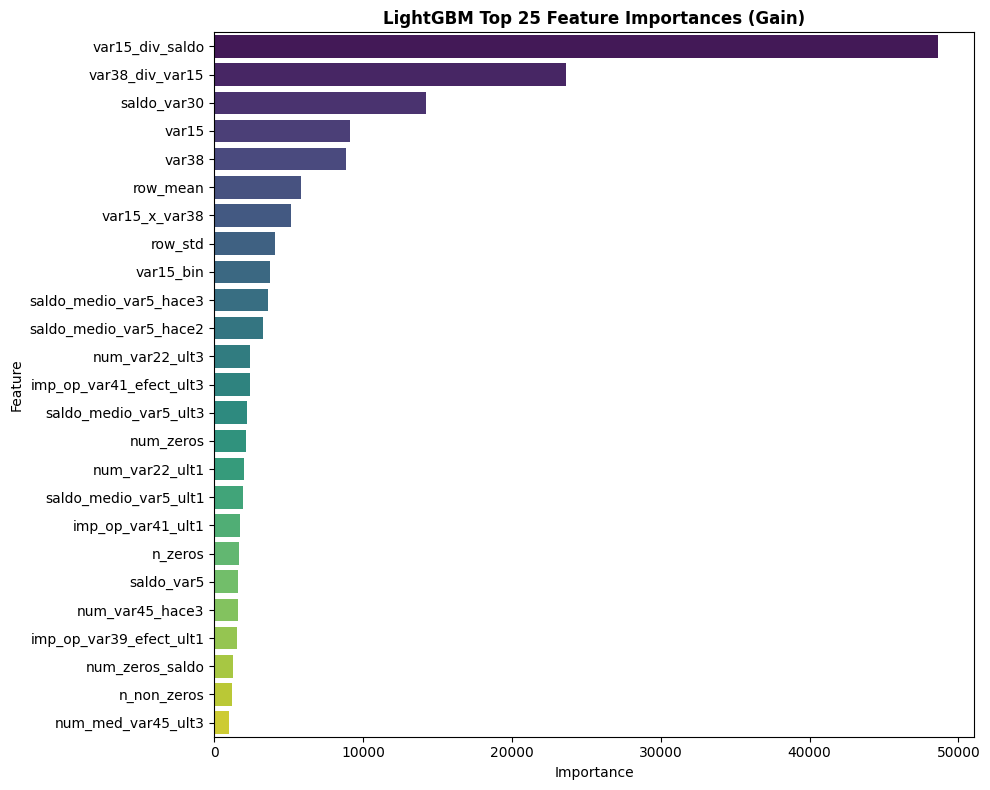

In [6]:
# Average feature importance across all 5 folds
feature_importances = np.zeros(len(X.columns))
for model in models:
    feature_importances += model.feature_importance(importance_type='gain') / len(models)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(25), palette='viridis')
plt.title('LightGBM Top 25 Feature Importances (Gain)', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Kaggle Submission
Generate the final `submission.csv` to evaluate our single-model baseline.


In [7]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'TARGET': test_preds
})

submission_path = '../submissions/lgbm_submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Kaggle Submission saved to {submission_path}")
print(submission.head())


✅ Kaggle Submission saved to ../submissions/lgbm_submission.csv
   ID    TARGET
0   2  0.036501
1   5  0.053593
2   6  0.002593
3   7  0.011661
4   9  0.002455
